<style>
.jp-Notebook, .notebook { max-width: 1000px; margin: 0 auto; }

div.text_cell_render {
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Arial, sans-serif;
    line-height: 1.6;
    color: #333;
}

h1, h2, h3, h4, h5, h6 {
    margin-top: 1.5em;
    margin-bottom: 0.5em;
    font-weight: 600;
    color: #2c6e9e;
}

h1 { font-size: 2em; border-bottom: 2px solid #2c6e9e; padding-bottom: 10px; }
h2 { font-size: 1.5em; border-bottom: 1px solid #ddd; padding-bottom: 5px; }
h3 { font-size: 1.3em; }

p, li { text-align: justify; }

.atencao, .box-warning {
    background-color: #fff3cd;
    border-left: 5px solid #ff9800;
    padding: 15px;
    border-radius: 8px;
    margin: 15px 0;
}
.info, .box-info {
    background-color: #e8f4fd;
    border-left: 5px solid #2196f3;
    padding: 15px;
    border-radius: 8px;
    margin: 15px 0;
}
.sucesso, .box-success {
    background-color: #e6f4ea;
    border-left: 5px solid #4caf50;
    padding: 15px;
    border-radius: 8px;
    margin: 15px 0;
}

table { border-collapse: collapse; width: 100%; margin: 15px 0; }
th, td { border: 1px solid #ddd; padding: 10px; text-align: left; }
th { background-color: #f2f2f2; font-weight: 600; }
</style>

<div style="max-width: 900px; margin: 0 auto; font-family: Arial, sans-serif; line-height: 1.6;">

<br>

<div align="center">
    <img src="
X9u0k/YOdr2lLWiu3/+ezLoWd1WMyO7FPDc4dtodGvMGwWMsRsbWmlFLWkPXR0XngnaOpr2fJe3xYonRFxTH/wHIBpxd2aZzVAAAAABJRU5ErkJggg" width="150"/>
</div>

<br>

<div align="center">
    <h1 style="font-size: 30px; font-weight: 900; margin: 0; padding: 0;">Projeto GEOTEC</h1>
</div>

---

<div align="center">
    <p style="font-size: 18px; margin-top: 10px; margin-bottom: 10px;">
        Capacitação em Geotecnologias para Monitoramento do Crédito Rural e do Proagro
    </p>
</div>

<div align="center">
    <p><b>Módulo:</b> Governança Territorial</p>
</div>

---

### Equipe

Pedro Coutinho, Gerd Sparovek, Alberto Barretto, Herbert Lincon, Marluce Scarabello, Pietro Gragnolati, Ana Beatriz Ferreira Macedo, Rodrigo Fernando Maule, João Marinho, João Gabriel Souza, Victor Hugo Bitu Patricio, Richard Torsiano

---

### Instituição
Instituto para Governança Territorial e Políticas Públicas (iGPP)

---

</div>

# Aulas 12 e 13 — Indicadores Fundiários
<hr style="border:1px solid #2c6e9e;">

Este notebook calcula a sobreposição de um imóvel rural (CAR) com todas as categorias fundiárias, e gera mensagens que definem o nível de alerta.

*Cobre as Aulas 12 (categorias possivelmente restritivas) e 13 (assentamentos e SIGEF/SNCI).*


<hr style="border:1px solid #2c6e9e;">

## 1. Pré-requisitos e Bibliotecas Utilizadas

### 1.1 Pré-requisitos Técnicos

<div class="atencao">
<b>ATENÇÃO:</b> Certifique-se de que todos os pré-requisitos abaixo estão atendidos antes de executar este notebook.
</div>

|| Pré-requisito | Detalhes |
|---|--------------|----------|
| 1 | **PostgreSQL 14+ com PostGIS 3+** rodando localmente | Banco `geotec` acessível em `localhost:5432` |
| 2 | **SRID 97823 cadastrado** no banco | Cônica Equivalente de Albers — Brasil. Não cadastrado? Ver [Aula_06/02_SRID_97823.ipynb](https://github.com/GPP-USP/GEOTEC-governanca-territorial/blob/main/Aula_06/02_SRID_97823.ipynb) |
| 3 | **Dados importados** via `01_import_dados.ipynb` | Todos os schemas listados na seção 1.3 devem existir |
| 4 | **Python 3.10+** com ambiente virtual ativo | Recomendado: `conda` ou `venv` |

### 1.2 Bibliotecas Utilizadas

| Biblioteca | Descrição |
|------------|-----------|
| `pandas` | Manipulação e análise de dados tabulares estruturados |
| `geopandas` | Extensão do pandas para dados geoespaciais (geometrias) |
| `sqlalchemy` | Conexão e execução de consultas em bancos de dados SQL |
| `psycopg2` | Driver PostgreSQL para conexão com bancos PostGIS |
| `urllib` | Codificação de strings para URLs (credenciais) |
| `matplotlib` | Visualização de dados e criação de gráficos |
| `folium` | Criação de mapas interativos para visualização web |
| `shapely` | Operações geométricas subjacentes (usado pelo geopandas) |
| `cartopy` | Visualização cartográfica avançada com projeções |
| `dotenv` | Carregamento de variáveis de ambiente (.env) |
| `os` | Operações com sistema de arquivos |
| `dataclasses` | Criação de classes de dados estruturadas |
| `IPython.display` | Exibição de elementos (Markdown, HTML) no notebook |

### 1.3 Dados Necessários no Banco

Os schemas e tabelas a seguir devem estar disponíveis no banco `geotec`:

| Schema | Tabela | Conteúdo | Fonte |
|--------|--------|----------|-------|
| `car` | `es_mt_car_20260406` | Cadastro Ambiental Rural — Mato Grosso | SICAR |
| `mma` | `pa_br_ucs_mma_2026` | Unidades de Conservação | MMA / ICMBio |
| `funai` | `pa_br_terrasindigenas_funai_2026` | Terras Indígenas | FUNAI |
| `incra` | `pa_br_territoriosquilombolas_incra_2026` | Territórios Quilombolas | INCRA |
| `incra` | `pa_br_assentamentos_incra_2026` | Projetos de Assentamento (ASSA / ASSB) | INCRA |
| `sfb` | `pa_br_cnfp_sfb_2024_retificado` | Cadastro Nacional de Florestas Públicas (retificado) | SFB |
| `malha` | `pa_mt_malhafundiaria_2025_cdt` | Malha Fundiária CDT 2025 | INCRA / CDT |
| `incra` | `pa_br_sigef_privado_incra_2026` | Imóveis privados — SIGEF | INCRA |
| `incra` | `pa_br_snci_privado_incra_2026` | Imóveis privados — SNCI | INCRA |
| `incra` | `pa_br_modulosfiscais_incra` | Módulos Fiscais por município | INCRA |

### 1.4 Como Usar

Execute as células em ordem com **Shift + Enter**. Para analisar um imóvel diferente, altere apenas o valor de `COD_IMOVEL` na **Célula 2 (Configuração)** e re-execute o notebook completo (**Kernel → Restart & Run All**).

In [ ]:
# Verificação do ambiente — rode esta célula antes de continuar
import sys, importlib

LIBS = [
    "pandas", "geopandas", "sqlalchemy", "psycopg2",
    "folium", "matplotlib", "shapely", "cartopy",
    "dotenv", "IPython",
]

print(f"Python: {sys.version.split()[0]}")
print(f"Ambiente: {sys.prefix}\n")

faltando = []
for lib in LIBS:
    try:
        mod = importlib.import_module(lib)
        ver = getattr(mod, '__version__', 'ok')
        print(f"  ✓ {lib:<18} {ver}")
    except ImportError:
        print(f"  ✗ {lib:<18} NÃO INSTALADO")
        faltando.append(lib)

if faltando:
    print(f"\n⚠️  Bibliotecas faltando: {', '.join(faltando)}")
    print("Retorne à Aula 06 e execute os comandos de configuração do ambiente no Miniforge Prompt antes de continuar.")
else:
    print("\n✓ Ambiente OK — pode continuar.")

Python: 3.12.13
Ambiente: c:\Users\vhbit\miniforge3\envs\geotec

  ✓ pandas             3.0.2
  ✓ geopandas          1.1.3
  ✓ sqlalchemy         2.0.49
  ✓ psycopg2           2.9.11 (dt dec pq3 ext lo64)
  ✓ folium             0.20.0
  ✓ matplotlib         3.10.8
  ✓ shapely            2.1.2
  ✓ cartopy            0.25.0
  ✓ dotenv             ok
  ✓ IPython            9.12.0

✓ Ambiente OK — pode continuar.


In [ ]:
import os
import urllib.parse

import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import folium

from sqlalchemy import create_engine, text
from IPython.display import HTML, display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
print("[OK] Bibliotecas importadas")

[OK] Bibliotecas importadas


<hr style="border:1px solid #2c6e9e;">

## 2. Conexão com o Banco e Parâmetros da Análise

<div class="atencao">
<b>ATENÇÃO:</b> Altere o <code>COD_IMOVEL</code> para o imóvel que deseja analisar.
Os imóveis de estudo de caso desta aula estão listados como comentário.
</div>

In [ ]:
# ============================================================================
# IMÓVEL DE INTERESSE - ALTERE ESTE VALOR
# ============================================================================
COD_IMOVEL = "MT-5105580-7CDBDD79B9374D0CA7CC274037AF531C"  # ASSA 100%

# Outros imóveis de estudo de caso:
# COD_IMOVEL = "MT-5106240-2C569B7AC0C34055986020860544229E"  # UCPI
# COD_IMOVEL = "MT-5103254-198BD8BDC80240CCA17196EC2558E146"  # UCUS
# COD_IMOVEL = "MT-5106265-62DB7655979E41A5BB9FA3A0CD2AF9BD"  # >15MF + GPFPND
# COD_IMOVEL = "MT-5106265-BD93832E1A6E4AAC88BED0095F569863"  # 100% GPFPND
# COD_IMOVEL = "MT-5102504-5785523723BB4AF7B87D7325A4563CB8"  # AM
# COD_IMOVEL = "MT-5107743-C61355B0E15B4A47B37774C8E0BBD951"  # TINH
# COD_IMOVEL = "MT-5106109-9F3831A8EBB949D0AE0E3F29615DA2C0"  # TQT
# COD_IMOVEL = "MT-5105580-9C4D98486B8D46AFAA2D4D07F16A878F"  # TIH
# COD_IMOVEL = "MT-5105580-7CDBDD79B9374D0CA7CC274037AF531C"  # ASSA 100%
# COD_IMOVEL = "MT-5106265-226BC30120774A5380D96DDA139D2D58"  # ASSA parcial
# COD_IMOVEL = "MT-5106265-A35D15E3CC304824A2855B9FE012012A"  # ASSB parcial
# COD_IMOVEL = "MT-5106265-56B65CEB67564E26AB8C82B232E856EF"  # ASSB 100%
# COD_IMOVEL = "MT-5106216-5E3DCE81A6AC4256B2571A3B50847BAC"  # SIGEF/SNCI 100%

# ============================================================================
# CONEXÃO - Banco local geotec
# ============================================================================
DB_USER     = "postgres"
DB_PASSWORD = "postgres"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "geotec"

# ============================================================================
# SCHEMAS E TABELAS NO BANCO LOCAL
# ============================================================================

# CAR - Mato Grosso
CAR_SCHEMA = "car"
CAR_TABLE  = "es_mt_car_20260406"
CAR_COD    = "cod_imovel"       # campo com código único do imóvel
CAR_GEOM   = "geometry"         # campo geometria
CAR_MF     = "mod_fiscal"       # valor de 1 módulo fiscal (ha) do município do imóvel

# Unidades de Conservação (MMA)
UC_SCHEMA  = "mma"
UC_TABLE   = "pa_br_ucs_mma_2026"
UC_GEOM    = "geometry"
UC_NOME    = "nome_uc"
UC_CAT     = "categoria"
UC_GRUPO   = "grupo"
# UCPI: IN ('Estação Ecológica','Reserva Biológica','Parque','Monumento Natural','Refúgio de Vida Silvestre')
# UCUS: IN ('Reserva Extrativista','Reserva de Desenvolvimento Sustentável','Floresta','Reserva Particular do Patrimônio Natural','Área de Proteção Ambiental','Área de Relevante Interesse Ecológico')

# Terras Indígenas (FUNAI)
TI_SCHEMA  = "funai"
TI_TABLE   = "pa_br_terrasindigenas_funai_2026"
TI_GEOM    = "geometry"
TI_NOME    = "terrai_nom"
TI_FASE    = "fase_ti"
# TIH : 'Homologada', 'Regularizada'
# TINH: 'Declarada', 'Delimitada', 'Em Estudo', 'Encaminhada RI'

# Territórios Quilombolas (INCRA)
TQ_SCHEMA  = "incra"
TQ_TABLE   = "pa_br_territoriosquilombolas_incra_2026"
TQ_GEOM    = "geometry"
TQ_NOME    = "nm_comunid"
TQ_FASE    = "fase"
# TQT: 'TITULADO', 'TITULO PARCIAL'
# TQNT: 'RTID', 'TITULO ANULADO', 'CCDRU', 'PORTARIA', 'DECRETO' ou fase nula

# Florestas Públicas + Áreas Militares (SFB/CNFP — retificado)
CNFP_SCHEMA = "sfb"
CNFP_TABLE  = "pa_br_cnfp_sfb_2024_retificado"
CNFP_GEOM    = "geometry"
CNFP_NOME    = "nome"
CNFP_CLASSE  = "classe"  # 'AREAMILIT' (e combinações) = Áreas Militares

# Malha Fundiária CDT (GP, GPFPND, ASRFG)
MALHA_SCHEMA = "malha"
MALHA_TABLE  = "pa_mt_malhafundiaria_2025_cdt"
MALHA_GEOM   = "geometry"
MALHA_CAT    = "categoria_fundiaria_v2025"
# 'GP', 'GPFPND', 'ASRFG'

# Assentamentos INCRA (ASSA / ASSB)
ASS_SCHEMA = "incra"
ASS_TABLE  = "pa_br_assentamentos_incra_2026"
ASS_GEOM   = "geometry"
ASS_NOME   = "nome_proje"
# ASSA: split_part(nome_proje,' ',1) IN ('PRB','PA','PAC','PC','PCA','PIC','PE')
# ASSB: split_part(nome_proje,' ',1) IN ('PAF','PDS','PAE')

# SIGEF/SNCI
SIGEF_SCHEMA = "incra"
SIGEF_TABLE  = "pa_br_sigef_privado_incra_2026"
SIGEF_GEOM   = "geometry"
SNCI_SCHEMA  = "incra"
SNCI_TABLE   = "pa_br_snci_privado_incra_2026"
SNCI_GEOM    = "geometry"

# Módulos Fiscais por município (INCRA)
MF_SCHEMA = "incra"
MF_TABLE  = "pa_br_modulosfiscais_incra"

print(f"Imóvel selecionado: {COD_IMOVEL}")

Imóvel selecionado: MT-5105580-7CDBDD79B9374D0CA7CC274037AF531C


In [ ]:
# Conexão com o banco
encoded_pw = urllib.parse.quote_plus(DB_PASSWORD)
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{encoded_pw}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print(f"[OK] Conectado ao banco {DB_NAME} em {DB_HOST}:{DB_PORT}")
except Exception as e:
    print(f"[ERRO] Falha na conexão: {e}")

[OK] Conectado ao banco geotec em localhost:5432


<hr style="border:1px solid #2c6e9e;">

## 3. Informações do Imóvel (CAR)

Consulta os dados basicos do imóvel: área, módulos fiscais e situação cadastral.

In [ ]:
query_car = f"""
SELECT
    c.{CAR_COD}                                                           AS cod_imovel,
    c.nom_tema                                                            AS nome,
    c.municipio,
    c.cod_estado                                                          AS uf,
    c.ind_status                                                          AS status,
    c.ind_tipo                                                            AS tipo,
    c.des_condic                                                          AS condicao,
    ROUND(c.num_area::numeric, 4)                                         AS area_declarada_ha,
    ROUND(ST_Area(ST_Transform(c.{CAR_GEOM}, 97823))::numeric / 10000, 4) AS area_calculada_ha,
    ROUND(c.{CAR_MF}::numeric, 4)                                         AS num_mf_car,
    mf.modulofiscal_ha                                                    AS modulo_fiscal_incra_ha,
    ROUND(
        (ST_Area(ST_Transform(c.{CAR_GEOM}, 97823)) / 10000 / NULLIF(mf.modulofiscal_ha, 0))
    ::numeric, 2)                                                         AS num_mf_incra
FROM {CAR_SCHEMA}.{CAR_TABLE} c
LEFT JOIN {MF_SCHEMA}.{MF_TABLE} mf
       ON SPLIT_PART(c.{CAR_COD}, '-', 2)::integer = mf.codibge
WHERE c.{CAR_COD} = '{COD_IMOVEL}'
"""

df_car = pd.read_sql(text(query_car), con=engine)

if df_car.empty:
    print(f"[ATENÇÃO] Imóvel não encontrado: {COD_IMOVEL}")
else:
    area_ha       = float(df_car["area_calculada_ha"].iloc[0])
    mf_incra_ha   = float(df_car["modulo_fiscal_incra_ha"].iloc[0] or 0)
    num_mf_incra  = float(df_car["num_mf_incra"].iloc[0] or 0)
    num_mf_car    = float(df_car["num_mf_car"].iloc[0] or 0)

    display(HTML(f"""
    <h3>Imóvel analisado: {df_car['cod_imovel'].iloc[0]}</h3>
    <table border='1' cellpadding='6' style='border-collapse:collapse; font-size:0.95em'>
      <tr><td><b>Código do Imóvel</b></td><td>{df_car['cod_imovel'].iloc[0]}</td></tr>
      <tr><td><b>Município / UF</b></td><td>{df_car['municipio'].iloc[0]} / {df_car['uf'].iloc[0]}</td></tr>
      <tr><td><b>Status</b></td><td>{df_car['status'].iloc[0]}</td></tr>
      <tr><td><b>Tipo</b></td><td>{df_car['tipo'].iloc[0]}</td></tr>
      <tr><td><b>Área Declarada</b></td><td>{df_car['area_declarada_ha'].iloc[0]:,.2f} ha</td></tr>
      <tr><td><b>Área Calculada</b></td><td>{area_ha:,.2f} ha</td></tr>
      <tr><td><b>Módulo Fiscal (INCRA)</b></td><td>{mf_incra_ha:,.0f} ha</td></tr>
      <tr><td><b>Nº de Módulos Fiscais (INCRA)</b></td><td>{num_mf_incra:,.2f} MF</td></tr>
      <tr><td><b>Nº de Módulos Fiscais (CAR)</b></td><td>{num_mf_car:,.2f} MF</td></tr>
    </table>
    """))

Código do Imóvel,MT-5105580-7CDBDD79B9374D0CA7CC274037AF531C
Município / UF,Marcelandia / MT
Status,AT
Tipo,IRU
Área Declarada,30.47 ha
Área Calculada,30.45 ha
Módulo Fiscal (INCRA),90 ha
Nº de Módulos Fiscais (INCRA),0.34 MF
Nº de Módulos Fiscais (CAR),0.34 MF


<hr style="border:1px solid #2c6e9e;">

## 4. Cálculo das Sobreposições

Calcula a area de sobreposição entre o CAR e cada categoria fundiária restritiva.
O SRID 97823 (Cônica Equivalente de Albers - Brasil) é utilizado para cálculo de área em hectares.

In [ ]:
def calcular_todas_sobreposicoes(engine, cod_imovel):
    """Calcula sobreposições de todas as categorias fundiárias em uma única query SQL."""
    q = f"""
    WITH car AS (
        SELECT {CAR_GEOM} AS geom,
               ST_Area(ST_Transform({CAR_GEOM}, 97823)) / 10000 AS area_ha
        FROM {CAR_SCHEMA}.{CAR_TABLE}
        WHERE {CAR_COD} = '{cod_imovel}'
    ),
    sob AS (

        -- UCPI - Proteção Integral
        SELECT 'UCPI'      AS categoria,
               l.{UC_NOME} AS nome,
               l.{UC_CAT}  AS tipo,
               ST_Area(ST_Transform(ST_Intersection(c.geom, l.{UC_GEOM}), 97823)) / 10000 AS area_ha
        FROM {UC_SCHEMA}.{UC_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{UC_GEOM})
          AND l.{UC_CAT} IN ('Estação Ecológica','Reserva Biológica','Parque','Monumento Natural','Refúgio de Vida Silvestre')

        UNION ALL

        -- UCUS - Uso Sustentável (RESEX, RDS, Floresta, RPPN, APA, ARIE)
        SELECT 'UCUS', l.{UC_NOME}, l.{UC_CAT},
               ST_Area(ST_Transform(ST_Intersection(c.geom, l.{UC_GEOM}), 97823)) / 10000
        FROM {UC_SCHEMA}.{UC_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{UC_GEOM})
          AND l.{UC_CAT} IN ('Reserva de Fauna','Reserva Extrativista','Reserva de Desenvolvimento Sustentável','Floresta','Reserva Particular do Patrimônio Natural','Área de Proteção Ambiental','Área de Relevante Interesse Ecológico')

        UNION ALL

        -- TIH - Terras Indígenas Homologadas
        -- Lógica: NOT IN fases não homologadas (alinhado ao pipeline CDT)
        SELECT 'TIH', l.{TI_NOME}, l.{TI_FASE},
               ST_Area(ST_Transform(ST_Intersection(c.geom, l.{TI_GEOM}), 97823)) / 10000
        FROM {TI_SCHEMA}.{TI_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{TI_GEOM})
          AND l.{TI_FASE} NOT IN ('Declarada', 'Delimitada', 'Em Estudo', 'Encaminhada RI')

        UNION ALL

        -- TINH - Terras Indígenas Não Homologadas
        SELECT 'TINH', l.{TI_NOME}, l.{TI_FASE},
               ST_Area(ST_Transform(ST_Intersection(c.geom, l.{TI_GEOM}), 97823)) / 10000
        FROM {TI_SCHEMA}.{TI_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{TI_GEOM})
          AND l.{TI_FASE} IN ('Declarada', 'Delimitada', 'Em Estudo', 'Encaminhada RI')

        UNION ALL

        -- TQT - Territórios Quilombolas Titulados
        -- Lógica: inclui TITULADO, TITULO PARCIAL
        SELECT 'TQT', l.{TQ_NOME}, l.{TQ_FASE},
               ST_Area(ST_Transform(ST_Intersection(c.geom, l.{TQ_GEOM}), 97823)) / 10000
        FROM {TQ_SCHEMA}.{TQ_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{TQ_GEOM})
          AND l.{TQ_FASE} IN ('TITULADO', 'TITULO PARCIAL')

        UNION ALL

        -- TQNT - Territórios Quilombolas Não Titulados
        SELECT 'TQNT', l.{TQ_NOME}, l.{TQ_FASE},
               ST_Area(ST_Transform(ST_Intersection(c.geom, l.{TQ_GEOM}), 97823)) / 10000
        FROM {TQ_SCHEMA}.{TQ_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{TQ_GEOM})
          AND (l.{TQ_FASE} IN ('RTID', 'TITULO ANULADO', 'CCDRU', 'PORTARIA', 'DECRETO') OR l.{TQ_FASE} IS NULL)

        UNION ALL

        -- GPFPND - Floresta Pública Não Destinada (Tipo B), consolidada por categoria
        SELECT 'GPFPND', NULL, NULL,
               ST_Area(ST_Transform(ST_UnaryUnion(ST_Collect(geom_intersecao)), 97823)) / 10000
        FROM (
            SELECT ST_Force2D(ST_CollectionExtract(ST_Intersection(c.geom, ST_MakeValid(l.{MALHA_GEOM})), 3)) AS geom_intersecao
            FROM {MALHA_SCHEMA}.{MALHA_TABLE} l CROSS JOIN car c
            WHERE ST_Intersects(c.geom, l.{MALHA_GEOM})
              AND l.{MALHA_CAT} = 'GPFPND'
        ) gpfpnd
        WHERE NOT ST_IsEmpty(geom_intersecao)

        UNION ALL

        -- GP - Gleba Pública, consolidada por categoria
        SELECT 'GP', NULL, NULL,
               ST_Area(ST_Transform(ST_UnaryUnion(ST_Collect(geom_intersecao)), 97823)) / 10000
        FROM (
            SELECT ST_Force2D(ST_CollectionExtract(ST_Intersection(c.geom, ST_MakeValid(l.{MALHA_GEOM})), 3)) AS geom_intersecao
            FROM {MALHA_SCHEMA}.{MALHA_TABLE} l CROSS JOIN car c
            WHERE ST_Intersects(c.geom, l.{MALHA_GEOM})
              AND l.{MALHA_CAT} = 'GP'
        ) gp
        WHERE NOT ST_IsEmpty(geom_intersecao)

        UNION ALL

        -- AM - Áreas Militares (CNFP retificado)
        SELECT 'AM', l.{CNFP_NOME}, l.{CNFP_CLASSE},
               ST_Area(ST_Transform(ST_Intersection(c.geom, l.{CNFP_GEOM}), 97823)) / 10000
        FROM {CNFP_SCHEMA}.{CNFP_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{CNFP_GEOM})
          AND l.{CNFP_CLASSE} ILIKE '%AREAMILIT%'

        UNION ALL

        -- ASRFG, consolidada por categoria
        SELECT 'ASRFG', NULL, NULL,
               ST_Area(ST_Transform(ST_UnaryUnion(ST_Collect(geom_intersecao)), 97823)) / 10000
        FROM (
            SELECT ST_Force2D(ST_CollectionExtract(ST_Intersection(c.geom, ST_MakeValid(l.{MALHA_GEOM})), 3)) AS geom_intersecao
            FROM {MALHA_SCHEMA}.{MALHA_TABLE} l CROSS JOIN car c
            WHERE ST_Intersects(c.geom, l.{MALHA_GEOM})
              AND l.{MALHA_CAT} = 'ASRFG'
        ) asrfg
        WHERE NOT ST_IsEmpty(geom_intersecao)

        UNION ALL

        -- ASSA - Assentamentos Convencionais (PA, PE, PAC, PC, PCA, PIC, PRB)
        SELECT 'ASSA', l.{ASS_NOME}, SPLIT_PART(l.{ASS_NOME}, ' ', 1),
               ST_Area(ST_Transform(ST_Intersection(c.geom, l.{ASS_GEOM}), 97823)) / 10000
        FROM {ASS_SCHEMA}.{ASS_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{ASS_GEOM})
          AND SPLIT_PART(l.{ASS_NOME}, ' ', 1) IN ('PRB','PA','PAC','PC','PCA','PIC','PE')
          AND ST_GeometryType(l.{ASS_GEOM}) IS NOT NULL

        UNION ALL

        -- ASSB - Assentamentos Sustentáveis (PAF, PDS, PAE)
        SELECT 'ASSB', l.{ASS_NOME}, SPLIT_PART(l.{ASS_NOME}, ' ', 1),
               ST_Area(ST_Transform(ST_Intersection(c.geom, l.{ASS_GEOM}), 97823)) / 10000
        FROM {ASS_SCHEMA}.{ASS_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{ASS_GEOM})
          AND SPLIT_PART(l.{ASS_NOME}, ' ', 1) IN ('PAF','PDS','PAE')

        UNION ALL

        -- SIGEF + SNCI - consolidado sem dupla contagem, ja recortado pelo CAR
        SELECT 'SIGEF_SNCI', NULL, NULL,
               ST_Area(ST_Transform(ST_Intersection(c.geom, sigef_snci.geom), 97823)) / 10000
        FROM car c
        CROSS JOIN (
            SELECT ST_Union(geom) AS geom
            FROM (
                SELECT ST_Force2D(ST_CollectionExtract(ST_MakeValid(l.{SIGEF_GEOM}), 3)) AS geom
                FROM {SIGEF_SCHEMA}.{SIGEF_TABLE} l CROSS JOIN car c
                WHERE ST_Intersects(c.geom, l.{SIGEF_GEOM})

                UNION ALL

                SELECT ST_Force2D(ST_CollectionExtract(ST_MakeValid(l.{SNCI_GEOM}), 3)) AS geom
                FROM {SNCI_SCHEMA}.{SNCI_TABLE} l CROSS JOIN car c
                WHERE ST_Intersects(c.geom, l.{SNCI_GEOM})
            ) bases
            WHERE NOT ST_IsEmpty(geom)
        ) sigef_snci
        WHERE sigef_snci.geom IS NOT NULL
    )
    SELECT
        s.categoria,
        s.nome,
        s.tipo,
        ROUND(s.area_ha::numeric, 4)                                         AS area_sobreposicao_ha,
        ROUND((s.area_ha / NULLIF(c.area_ha, 0) * 100)::numeric, 2) AS perc_sobreposicao
    FROM sob s CROSS JOIN car c
    WHERE s.area_ha > 0
    ORDER BY s.categoria, area_sobreposicao_ha DESC
    """
    return pd.read_sql(text(q), con=engine)


print("[OK] Query consolidada de sobreposições carregada (1 query = 13 categorias)")

[OK] Query consolidada de sobreposições carregada (1 query = 13 categorias)


### 4.1 Preparação das Sobreposições

Esta célula executa a consulta consolidada, carrega `df_sob` e prepara os subconjuntos e indicadores que serão usados nos blocos temáticos seguintes.

In [ ]:
# ============================================================================
# 4.1 Preparação dos dados de sobreposição
# ============================================================================
df_sob = calcular_todas_sobreposicoes(engine, COD_IMOVEL)

# Fases TINH usadas pelo mapa (TIH = NOT IN estas; alinhado ao pipeline CDT)
TINH_FASES     = "'Declarada','Delimitada','Em Estudo','Encaminhada RI'"
TQNT_FASE_LIST = "'RTID','TITULO ANULADO','CCDRU','PORTARIA','DECRETO'"  # TQNT = fases nao tituladas ou sem fase

def _cat(cat):
    return df_sob[df_sob["categoria"] == cat].reset_index(drop=True)

def _area(cat):
    return _cat(cat)["area_sobreposicao_ha"].sum()

def _perc(cat):
    return _cat(cat)["perc_sobreposicao"].sum()

def mostrar_proximas_se_interseccao(tem_interseccao, titulo, schema, table, geom_col,
                                    nome_expr, tipo_expr=None, filtro_extra="", limite=5):
    """Mostra feições mais próximas apenas quando já existe interseção na categoria."""
    if not tem_interseccao:
        return

    where_parts = [f"l.{geom_col} IS NOT NULL"]
    if filtro_extra:
        where_parts.append(f"({filtro_extra})")
    where = " AND ".join(where_parts)
    tipo_sql = tipo_expr if tipo_expr else "NULL::text"

    q = f"""
    WITH car AS (
        SELECT {CAR_GEOM} AS geom
        FROM {CAR_SCHEMA}.{CAR_TABLE}
        WHERE {CAR_COD} = '{COD_IMOVEL}'
    )
    SELECT
        {nome_expr} AS nome,
        {tipo_sql} AS tipo_fase,
        ST_Intersects(l.{geom_col}, c.geom) AS intersecta,
        ROUND(
            ST_Distance(
                ST_Transform(c.geom, 97823),
                ST_Transform(l.{geom_col}, 97823)
            )::numeric / 1000, 3
        ) AS distancia_km
    FROM {schema}.{table} l CROSS JOIN car c
    WHERE {where}
    ORDER BY ST_Distance(ST_Transform(c.geom, 97823), ST_Transform(l.{geom_col}, 97823))
    LIMIT {int(limite)}
    """
    df_proximas = pd.read_sql(text(q), con=engine)
    if not df_proximas.empty:
        display(_subtitulo(titulo))
        display(df_proximas.style.hide(axis="index"))

def _html_resumo(*linhas, inverter=False):
    rows = ""
    for label, area, perc in linhas:
        cor = ("#27ae60" if area > 0 else "#c0392b") if inverter else ("#c0392b" if area > 0 else "#27ae60")
        rows += (
            f'<tr>'
            f'<td style="padding:3px 14px 3px 0;color:#444">{label}</td>'
            f'<td style="padding:3px 10px;text-align:right;font-weight:600;color:{cor}">{area:,.4f} ha</td>'
            f'<td style="padding:3px 0;text-align:right;color:#777;min-width:65px">{perc:.2f}%</td>'
            f'</tr>'
        )
    return HTML(f'<table style="border-collapse:collapse;font-size:.9em;margin:4px 0 10px">{rows}</table>')

def _subtitulo(texto):
    return HTML(
        f'<div style="font-weight:600;font-size:.9em;margin:10px 0 4px;'
        f'border-left:3px solid #2c6e9e;padding-left:8px;color:#1a1a1a">{texto}</div>'
    )

df_ucpi     = _cat("UCPI");   ucpi_area   = _area("UCPI");   ucpi_perc   = _perc("UCPI")
df_ucus     = _cat("UCUS");   ucus_area   = _area("UCUS");   ucus_perc   = _perc("UCUS")
df_tih      = _cat("TIH");    tih_area    = _area("TIH");    tih_perc    = _perc("TIH")
df_tinh     = _cat("TINH");   tinh_area   = _area("TINH");   tinh_perc   = _perc("TINH")
df_tqt      = _cat("TQT");    tqt_area    = _area("TQT");    tqt_perc    = _perc("TQT")
df_tqnt     = _cat("TQNT");   tqnt_area   = _area("TQNT");   tqnt_perc   = _perc("TQNT")
df_gpfpnd   = _cat("GPFPND"); gpfpnd_area = _area("GPFPND"); gpfpnd_perc = _perc("GPFPND")
df_gp       = _cat("GP");     gp_area     = _area("GP");     gp_perc     = _perc("GP")
df_am       = _cat("AM");     am_area     = _area("AM");     am_perc     = _perc("AM")
df_asrfg    = _cat("ASRFG");  asrfg_area  = _area("ASRFG");  asrfg_perc  = _perc("ASRFG")
df_assa     = _cat("ASSA");   assa_area   = _area("ASSA");   assa_perc   = _perc("ASSA")
df_assb     = _cat("ASSB");   assb_area   = _area("ASSB");   assb_perc   = _perc("ASSB")
df_sigef_snci = _cat("SIGEF_SNCI"); sigef_snci_area = _area("SIGEF_SNCI"); sigef_snci_perc = _perc("SIGEF_SNCI")

print(f"[OK] {len(df_sob)} sobreposições encontradas em {df_sob['categoria'].nunique()} categorias (1 query ao banco)")


[OK] 1 sobreposições encontradas em 1 categorias (1 query ao banco)


### 4.2 Unidades de Conservação

Este bloco apresenta separadamente as sobreposições com Unidades de Conservação de Proteção Integral (`UCPI`) e de Uso Sustentável (`UCUS`).

In [ ]:
# ============================================================================
# 4.2 Unidades de Conservação
# ============================================================================
display(_html_resumo(
    ("UCPI — Proteção Integral", ucpi_area, ucpi_perc),
    ("UCUS — Uso Sustentável",   ucus_area, ucus_perc),
))
if not df_ucpi.empty:
    display(_subtitulo("UCPI — Proteção Integral"))
    display(df_ucpi.style.hide(axis="index"))
if not df_ucus.empty:
    display(_subtitulo("UCUS — Uso Sustentável"))
    display(df_ucus.style.hide(axis="index"))

filtro_uc_restritiva = f"l.{UC_CAT} IN ('Estação Ecológica','Reserva Biológica','Parque','Monumento Natural','Refúgio de Vida Silvestre','Reserva de Fauna','Reserva Extrativista','Reserva de Desenvolvimento Sustentável','Floresta','Reserva Particular do Patrimônio Natural','Área de Proteção Ambiental','Área de Relevante Interesse Ecológico')"
mostrar_proximas_se_interseccao(
    ucpi_area > 0 or ucus_area > 0,
    "Unidades de Conservação mais próximas do imóvel:",
    UC_SCHEMA, UC_TABLE, UC_GEOM,
    f"l.{UC_NOME}", f"l.{UC_CAT}", filtro_uc_restritiva
)


UCPI — Proteção Integral,0.0000 ha,0.00%
UCUS — Uso Sustentável,0.0000 ha,0.00%


### 4.3 Terras Indígenas

Aqui são exibidas as sobreposições com Terras Indígenas homologadas (`TIH`) e não homologadas (`TINH`), listando detalhes apenas quando houver interseção com o imóvel.

In [ ]:
# ============================================================================
# 4.3 Terras Indígenas
# ============================================================================
display(_html_resumo(
    ("TIH — Terra Indígena Homologada/Regularizada", tih_area,  tih_perc),
    ("TINH — Terra Indígena Não Homologada",         tinh_area, tinh_perc),
))
if not df_tih.empty:
    display(_subtitulo("TIH — Terra Indígena Homologada"))
    display(df_tih.style.hide(axis="index"))
if not df_tinh.empty:
    display(_subtitulo("TINH — Terra Indígena Não Homologada"))
    display(df_tinh.style.hide(axis="index"))

mostrar_proximas_se_interseccao(
    tih_area > 0 or tinh_area > 0,
    "Terras Indígenas mais próximas do imóvel:",
    TI_SCHEMA, TI_TABLE, TI_GEOM,
    f"l.{TI_NOME}", f"l.{TI_FASE}"
)

TIH — Terra Indígena Homologada/Regularizada,0.0000 ha,0.00%
TINH — Terra Indígena Não Homologada,0.0000 ha,0.00%


### 4.4 Territórios Quilombolas

Este bloco apresenta as sobreposições com Territórios Quilombolas titulados (`TQT`) e não titulados (`TQNT`).

In [ ]:
# ============================================================================
# 4.4 Territórios Quilombolas
# ============================================================================
display(_html_resumo(
    ("TQT — Território Quilombola Titulado",      tqt_area,  tqt_perc),
    ("TQNT — Território Quilombola Não Titulado", tqnt_area, tqnt_perc),
))
if not df_tqt.empty:
    display(_subtitulo("TQT — Território Quilombola Titulado"))
    display(df_tqt.style.hide(axis="index"))
if not df_tqnt.empty:
    display(_subtitulo("TQNT — Território Quilombola Não Titulado"))
    display(df_tqnt.style.hide(axis="index"))

mostrar_proximas_se_interseccao(
    tqt_area > 0 or tqnt_area > 0,
    "Territórios Quilombolas mais próximos do imóvel:",
    TQ_SCHEMA, TQ_TABLE, TQ_GEOM,
    f"l.{TQ_NOME}", f"l.{TQ_FASE}"
)

TQT — Território Quilombola Titulado,0.0000 ha,0.00%
TQNT — Território Quilombola Não Titulado,0.0000 ha,0.00%


### 4.5 Glebas Públicas e Florestas Públicas Não Destinadas

Aqui são exibidas as sobreposições com `GPFPND` e `GP` da Malha Fundiária CDT 2025.

In [ ]:
# ============================================================================
# 4.5 GP e GPFPND (Malha Fundiária 2025)
# ============================================================================
display(_html_resumo(
    ("GPFPND — Floresta Pública Não Destinada (Tipo B)", gpfpnd_area, gpfpnd_perc),
    ("GP — Gleba Pública",                               gp_area,     gp_perc),
))


GPFPND — Floresta Pública Não Destinada (Tipo B),0.0000 ha,0.00%
GP — Gleba Pública,0.0000 ha,0.00%


### 4.6 Áreas Militares

Este bloco mostra a sobreposição com Áreas Militares (`AM`) a partir do CNFP retificado.

In [ ]:
# ============================================================================
# 4.6 Áreas Militares
# ============================================================================
display(_html_resumo(("AM — Áreas Militares", am_area, am_perc)))
if not df_am.empty:
    display(_subtitulo("AM — Áreas Militares"))
    display(df_am.style.hide(axis="index"))

mostrar_proximas_se_interseccao(
    am_area > 0,
    "Áreas Militares mais próximas do imóvel:",
    CNFP_SCHEMA, CNFP_TABLE, CNFP_GEOM,
    f"l.{CNFP_NOME}", f"l.{CNFP_CLASSE}", f"l.{CNFP_CLASSE} ILIKE '%%AREAMILIT%%'"
)

AM — Áreas Militares,0.0000 ha,0.00%


### 4.7 Áreas Sem Registro Fundiário Georreferenciado

Este bloco apresenta as sobreposições com `ASRFG` da Malha Fundiária CDT 2025.

In [ ]:
# ============================================================================
# 4.7 Áreas Sem Registro Fundiário Georreferenciado
# ============================================================================
display(_html_resumo(("ASRFG — Área Sem Registro Fundiário Georreferenciado", asrfg_area, asrfg_perc), inverter=True))


ASRFG — Área Sem Registro Fundiário Georreferenciado,0.0000 ha,0.00%


### 4.8 Assentamentos

Este bloco apresenta separadamente os assentamentos convencionais (`ASSA`) e sustentáveis (`ASSB`).

In [ ]:
# ============================================================================
# 4.8 Assentamentos
# ============================================================================
display(_html_resumo(
    ("ASSA — Assentamento Convencional", assa_area, assa_perc),
    ("ASSB — Assentamento Sustentável",  assb_area, assb_perc),
))
if not df_assa.empty:
    display(_subtitulo("ASSA — Assentamento Convencional"))
    display(df_assa.style.hide(axis="index"))
if not df_assb.empty:
    display(_subtitulo("ASSB — Assentamento Sustentável"))
    display(df_assb.style.hide(axis="index"))


ASSA — Assentamento Convencional,30.4463 ha,100.00%
ASSB — Assentamento Sustentável,0.0000 ha,0.00%


categoria,nome,tipo,area_sobreposicao_ha,perc_sobreposicao
ASSA,PA BONJAGUÁ,PA,30.446300,100.000000


### 4.9 SIGEF + SNCI

Este bloco apresenta a união das sobreposições do imóvel com as bases SIGEF e SNCI, evitando dupla contagem de áreas coincidentes.

In [ ]:
# ============================================================================
# 4.9 SIGEF + SNCI
# ============================================================================
display(_html_resumo(("SIGEF + SNCI — Imóveis privados georreferenciados", sigef_snci_area, sigef_snci_perc), inverter=True))

if not df_sigef_snci.empty:
    q_sigef_snci_feicoes = f"""
    WITH car AS (
        SELECT {CAR_GEOM} AS geom,
               ST_Area(ST_Transform({CAR_GEOM}, 97823)) / 10000 AS area_ha
        FROM {CAR_SCHEMA}.{CAR_TABLE}
        WHERE {CAR_COD} = '{COD_IMOVEL}'
    ), feicoes AS (
        SELECT 'SIGEF' AS base,
               l.nome_area::text AS nome,
               l.codigo_imo::text AS codigo,
               l.status::text AS situacao,
               ST_Area(ST_Transform(ST_Intersection(c.geom, ST_MakeValid(l.{SIGEF_GEOM})), 97823)) / 10000 AS area_ha
        FROM {SIGEF_SCHEMA}.{SIGEF_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{SIGEF_GEOM})

        UNION ALL

        SELECT 'SNCI' AS base,
               l.nome_imove::text AS nome,
               l.cod_imovel::text AS codigo,
               l.num_certif::text AS situacao,
               ST_Area(ST_Transform(ST_Intersection(c.geom, ST_MakeValid(l.{SNCI_GEOM})), 97823)) / 10000 AS area_ha
        FROM {SNCI_SCHEMA}.{SNCI_TABLE} l CROSS JOIN car c
        WHERE ST_Intersects(c.geom, l.{SNCI_GEOM})
    )
    SELECT
        f.base AS "Base",
        f.nome AS "Feição",
        f.codigo AS "Código",
        f.situacao AS "Situação/Certificado",
        ROUND(f.area_ha::numeric, 4) AS "Área sobreposta (ha)",
        ROUND((f.area_ha / NULLIF(c.area_ha, 0) * 100)::numeric, 2) AS "% do imóvel"
    FROM feicoes f CROSS JOIN car c
    WHERE f.area_ha > 0
    ORDER BY f.area_ha DESC
    """
    df_sigef_snci_feicoes = pd.read_sql(text(q_sigef_snci_feicoes), con=engine)

    if not df_sigef_snci_feicoes.empty:
        display(_subtitulo("Feições SIGEF/SNCI com sobreposição"))
        display(HTML("<small>As áreas individuais abaixo podem se sobrepor entre si; o total consolidado correto é o quadro acima.</small>"))
        display(df_sigef_snci_feicoes.style.hide(axis="index"))


SIGEF + SNCI — Imóveis privados georreferenciados,0.0000 ha,0.00%


### 4.10 Tabela Resumo de Sobreposições

Esta seção agrega o `df_sob` em uma tabela final para comparação entre todas as categorias.

,Categoria,Área (ha),% do Imóvel
0,UCPI - Proteção Integral,0.0000,0.00%
1,UCUS - Uso Sustentável,0.0000,0.00%
2,TIH - Terra Indígena Homologada,0.0000,0.00%
3,TINH - TI Não Homologada,0.0000,0.00%
4,TQT - Território Quilombola Titulado,0.0000,0.00%
5,TQNT - TQ Não Titulado,0.0000,0.00%
6,GPFPND - Floresta Pública Tipo B,0.0000,0.00%
7,GP - Gleba Pública,0.0000,0.00%
8,AM - Área Militar,0.0000,0.00%
9,ASRFG - Área Sem Registro Fundiário Georrefere...,0.0000,0.00%


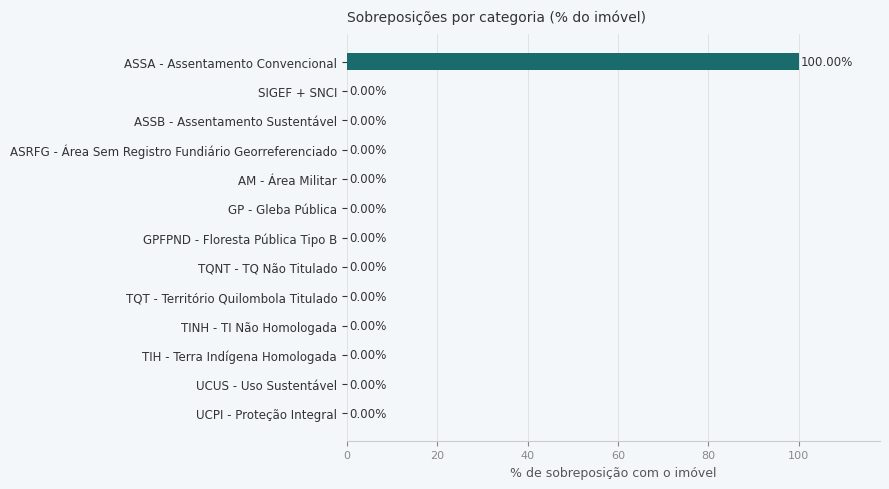

In [ ]:
# ============================================================================
# 4.10 Tabela Resumo de Sobreposições (agregada do df_sob)
# ============================================================================

LABEL_CAT = {
    "UCPI":  "UCPI - Proteção Integral",
    "UCUS":  "UCUS - Uso Sustentável",
    "TIH":   "TIH - Terra Indígena Homologada",
    "TINH":  "TINH - TI Não Homologada",
    "TQT":   "TQT - Território Quilombola Titulado",
    "TQNT":  "TQNT - TQ Não Titulado",
    "GPFPND":"GPFPND - Floresta Pública Tipo B",
    "GP":    "GP - Gleba Pública",
    "AM":    "AM - Área Militar",
    "ASRFG": "ASRFG - Área Sem Registro Fundiário Georreferenciado",
    "ASSA":  "ASSA - Assentamento Convencional",
    "ASSB":  "ASSB - Assentamento Sustentável",
    "SIGEF_SNCI": "SIGEF + SNCI",
}
ORDEM = ["UCPI","UCUS","TIH","TINH","TQT","TQNT","GPFPND","GP","AM","ASRFG","ASSA","ASSB","SIGEF_SNCI"]

df_resumo = (
    df_sob
    .assign(Categoria=df_sob["categoria"].map(LABEL_CAT).fillna(df_sob["categoria"]))
    .groupby("Categoria", as_index=False)
    .agg(**{"Área (ha)": ("area_sobreposicao_ha", "sum"), "% do Imóvel": ("perc_sobreposicao", "sum")})
)

# Adicionar categorias sem sobreposição com zero
labels_existentes = set(df_resumo["Categoria"].values)
for cat in ORDEM:
    label = LABEL_CAT.get(cat, cat)
    if label not in labels_existentes:
        df_resumo = pd.concat(
            [df_resumo, pd.DataFrame([{"Categoria": label, "Área (ha)": 0.0, "% do Imóvel": 0.0}])],
            ignore_index=True
        )
        labels_existentes.add(label)

ordem_map = {LABEL_CAT.get(c, c): i for i, c in enumerate(ORDEM)}
df_resumo["_ord"] = df_resumo["Categoria"].map(ordem_map).fillna(99)
df_resumo = df_resumo.sort_values("_ord").drop(columns="_ord").reset_index(drop=True)

df_resumo_fmt = df_resumo.copy()
df_resumo_fmt["Área (ha)"]   = df_resumo_fmt["Área (ha)"].apply(lambda x: f"{x:,.4f}")
df_resumo_fmt["% do Imóvel"] = df_resumo_fmt["% do Imóvel"].apply(lambda x: f"{x:.2f}%")

display(HTML("<h3>Resumo das Sobreposições</h3>"))
display(df_resumo_fmt)


# ── Gráfico de barras horizontais ──────────────────────────────────────────
COR_CAT = {
    "UCPI - Proteção Integral":                        "#004d00",
    "UCUS - Uso Sustentável":                          "#6dbf67",
    "TIH - Terra Indígena Homologada":                 "#d4691c",
    "TINH - TI Não Homologada":                        "#f0b080",
    "TQT - Território Quilombola Titulado":            "#6b1a6b",
    "TQNT - TQ Não Titulado":                          "#c080c0",
    "GPFPND - Floresta Pública Tipo B":                "#8b0000",
    "GP - Gleba Pública":                              "#cd5c5c",
    "AM - Área Militar":                               "#2c3e50",
    "ASRFG - Área Sem Registro Fundiário Georreferenciado": "#8a817c",
    "ASSA - Assentamento Convencional":                "#1a6b6b",
    "ASSB - Assentamento Sustentável":                 "#80c0c0",
    "SIGEF + SNCI":                                    "#1a4a6b",
}

df_graf = df_resumo.copy()
df_graf = df_graf.sort_values("% do Imóvel", ascending=True)

cores  = [COR_CAT.get(c, "#aaaaaa") for c in df_graf["Categoria"]]
perc   = df_graf["% do Imóvel"].values
labels = df_graf["Categoria"].values

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#f4f7fa")
ax.set_facecolor("#f4f7fa")

bars = ax.barh(labels, perc, color=cores, height=0.6, zorder=2)

# Rótulos no final de cada barra
for bar, val in zip(bars, perc):
    x = bar.get_width()
    ax.text(x + 0.4, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}%", va="center", ha="left",
            fontsize=8.5, color="#333")

ax.set_xlabel("% de sobreposição com o imóvel", fontsize=9, color="#555")
ax.set_xlim(0, max(perc.max() * 1.18, 5))
ax.tick_params(axis="y", labelsize=8.5, colors="#333")
ax.tick_params(axis="x", labelsize=8, colors="#888")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#ccc")
ax.xaxis.grid(True, color="#ddd", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

plt.title("Sobreposições por categoria (% do imóvel)", fontsize=10,
          color="#333", pad=10, loc="left")
plt.tight_layout()
plt.show()


<hr style="border:1px solid #2c6e9e;">

## 5. Mensagens do Indicador

Esta seção consolida, em um **único indicador fundiário**, todas as categorias analisadas neste notebook.

O resultado é organizado em dois níveis:
- **Status principal**: selecionado por hierarquia definida entre as categorias fundiárias, da mais restritiva para a menos restritiva.
- **Análises complementares**: sugestões de análises complementares que podem contribuir com o diagnóstico da situação fundiária do imóvel.

A hierarquia aplicada ao status principal é:
- **Impedimentos**: UCPI, UCUS, TQT, TIH, GPFPND total, ou GPFPND parcial em imóvel com mais de 15 MF
- **Alto risco fundiário**: Áreas Militares (AM), Terras Indígenas não Homologadas (TINH) e Territórios Quilombolas não Titulados (TQNT)
- **Risco fundiário moderado**: sobreposições totais ou parciais relevantes com assentamentos (ASSA e ASSB)
- **Baixo risco fundiário**: sobreposição total com SIGEF/SNCI.

Os indicadores podem se acumular, por exemplo, quando há uma sobreposição que configura impedimento e outra que configura um risco moderado. Nesse caso, será reportada a sobreposição mais crítica.

As sobreposições com Glebas Públicas e Áreas sem Registro Fundiário Georreferenciado serão tratadas na próxima aula.

In [ ]:
# ============================================================================
# HIERARQUIA DE MENSAGENS DO INDICADOR FUNDIÁRIO - CMN nº 5.268
# Status principal por hierarquia + detalhes complementares acumuláveis
# ============================================================================
status_principal = None
mensagens = []
detalhes_complementares = []

TITULO_IMPEDIMENTO  = "IMPEDIMENTO - CMN nº 5.268"
TITULO_RISCO_ALTO   = "ALTO RISCO FUNDIÁRIO"
TITULO_RISCO_FUTURO = "ALTO RISCO FUNDIÁRIO FUTURO"
TITULO_OBSERVACAO   = "OBSERVAÇÃO FUNDIÁRIA - RISCO FUNDIÁRIO MODERADO"
TITULO_CONFORMIDADE = "BAIXO RISCO FUNDIÁRIO"

# Limiares
LIMIAR_TOTAL              = 99.0   # >=99%   sobreposição total com assentamento
LIMIAR_TOTAL_GPFPND       = 99.0   # >=99%   sobreposição total com GPFPND
LIMIAR_TOTAL_SIGEF_SNCI   = 99.0   # >=99%   sobreposição total com SIGEF/SNCI
# Limiar parcial relevante varia conforme o tamanho do imóvel (módulos fiscais)
if num_mf_incra < 4:
    LIMIAR_PARCIAL_RELEVANTE = 10.0  # pequeno < 4 MF
elif num_mf_incra <= 15:
    LIMIAR_PARCIAL_RELEVANTE = 5.0   # médio 4–15 MF
else:
    LIMIAR_PARCIAL_RELEVANTE = 3.0   # grande > 15 MF

# Estilos — cores alinhadas ao arquivo support_files/cores_de_alertas.png
_BASE = "padding:10px 14px;border-radius:4px;margin:8px 0;background:#fafafa;border:1px solid #e8e8e8"
CSS_NIVEL1 = _BASE, "#c00000"  # impedimento absoluto
CSS_NIVEL2 = _BASE, "#ff5050"  # alto risco ativo (AM)
CSS_NIVEL3 = _BASE, "#ff8c00"  # alto risco futuro (TINH, TQNT)
CSS_NIVEL4 = _BASE, "#ffc000"  # risco moderado (assentamentos)
CSS_NIVEL5 = _BASE, "#078950"  # baixo risco fundiário


def nova_msg(titulo, msg, nivel):
    return {"titulo": titulo, "msg": msg, "nivel": nivel}


def _caixa_alerta(cor):
    estilos = {
        "#c00000": "background:#f8d7da;border-left:5px solid #c00000;padding:12px 15px;border-radius:4px;margin:8px 0;color:#4a1f24",
        "#ff5050": "background:#fde7e9;border-left:5px solid #ff5050;padding:12px 15px;border-radius:4px;margin:8px 0;color:#5a1c1f",
        "#ffc000": "background:#fff3cd;border-left:5px solid #ffc000;padding:12px 15px;border-radius:4px;margin:8px 0;color:#5c4400",
        "#078950": "background:#d4edda;border-left:5px solid #078950;padding:12px 15px;border-radius:4px;margin:8px 0;color:#0a3d1c",
    }
    return estilos.get(cor, "background:#e9ecef;border-left:5px solid #6c757d;padding:12px 15px;border-radius:4px;margin:8px 0;color:#212529")


def render_msg(item):
    _css, cor = item["nivel"]
    estilo = _caixa_alerta(cor)
    return f'<div style="{estilo}"><b>{item["titulo"]}</b><br>{item["msg"]}</div>'


def render_indicador_html(status_principal, detalhes_complementares=None, descricao=None):
    detalhes_complementares = detalhes_complementares or []
    blocos_html = ["<h3>Output do indicador</h3>"]
    if descricao:
        blocos_html.append(f"<p style='font-size:0.9em;color:#666'>{descricao}</p>")
    blocos_html.extend([
        "<div style='font-size:0.9em;color:#666;margin:4px 0 6px'><b>Status principal</b></div>",
        render_msg(status_principal),
    ])
    if detalhes_complementares:
        blocos_html.append("<div style='font-size:0.9em;color:#666;margin:14px 0 6px'><b>Detalhes complementares</b></div>")
        blocos_html.extend(render_msg(item) for item in detalhes_complementares)
    return "".join(blocos_html)


# ----------------------------------------------------------------------------
# IMPEDIMENTOS (exclusivos entre si dentro deste bloco)
# ----------------------------------------------------------------------------
impedimento = None
cats_impedidas = []
if ucpi_area > 0:
    cats_impedidas.append("Unidade de Conservação de Proteção Integral (UCPI)")
if ucus_area > 0:
    cats_impedidas.append("Unidade de Conservação de Uso Sustentável (UCUS)")
if tqt_area > 0:
    cats_impedidas.append("Território Quilombola Titulado (TQT)")
if tih_area > 0:
    cats_impedidas.append("Terra Indígena Homologada (TIH)")

if cats_impedidas:
    cats_str = "; ".join(cats_impedidas)
    impedimento = nova_msg(
        TITULO_IMPEDIMENTO,
        f"Imóvel possivelmente impedido de acessar o crédito rural por sobreposição com {cats_str}, de acordo com a CMN nº 5.268.",
        CSS_NIVEL1,
    )
elif gpfpnd_perc >= LIMIAR_TOTAL_GPFPND:
    impedimento = nova_msg(
        TITULO_IMPEDIMENTO,
        "Imóvel possivelmente impedido de acessar o crédito rural por estar totalmente sobreposto a uma Floresta Pública do Tipo B "
        f"({gpfpnd_perc:.1f}%), de acordo com a CMN nº 5.268, salvo se o proprietário apresentar o título de propriedade.",
        CSS_NIVEL1,
    )
elif gpfpnd_area > 0 and num_mf_incra > 15:
    impedimento = nova_msg(
        TITULO_IMPEDIMENTO,
        "Imóvel possivelmente impedido de acessar o crédito rural por possuir sobreposição parcial com Floresta Pública do Tipo B "
        f"e mais de 15 MF ({num_mf_incra:.2f} MF), de acordo com a CMN nº 5.268, salvo se o proprietário apresentar o título de propriedade.",
        CSS_NIVEL1,
    )

# ----------------------------------------------------------------------------
# RISCOS FUNDIARIOS
# ----------------------------------------------------------------------------
riscos_altos = []
riscos_futuros = []
if am_area > 0:
    riscos_altos.append(
        nova_msg(
            TITULO_RISCO_ALTO,
            f"Imóvel com sobreposição de {am_area:,.2f} ha com uma Área Militar, representando {am_perc:.1f}% da área do imóvel. "
            "Esta sobreposição pode representar alto risco fundiário ao imóvel, pois se trata de terra pública de alto interesse da União.",
            CSS_NIVEL2,
        )
    )

if tinh_area > 0:
    riscos_futuros.append(
        nova_msg(
            TITULO_RISCO_FUTURO,
            f"Imóvel com sobreposição de {tinh_area:,.2f} ha com uma Terra Indígena não Homologada, representando {tinh_perc:.1f}% da área do imóvel. "
            "Esta sobreposição pode representar risco à atividade produtiva do imóvel, pois, caso a terra indígena seja homologada, "
            "o proprietário poderá sofrer ação de desintrusão.",
            CSS_NIVEL3,
        )
    )

if tqnt_area > 0:
    riscos_futuros.append(
        nova_msg(
            TITULO_RISCO_FUTURO,
            f"Imóvel com sobreposição de {tqnt_area:,.2f} ha com um Território Quilombola não Titulado, representando {tqnt_perc:.1f}% da área do imóvel. "
            "Esta sobreposição pode representar risco à atividade produtiva do imóvel, pois, após a assinatura do decreto pelo Presidente da República, "
            "inicia-se o processo de desapropriação ou desintrusão, em caso de posses.",
            CSS_NIVEL3,
        )
    )

# ----------------------------------------------------------------------------
# OBSERVACOES FUNDIARIAS - ASSENTAMENTOS
# ----------------------------------------------------------------------------
observacoes = []
if assa_perc >= LIMIAR_TOTAL:
    observacoes.append(
        nova_msg(
            TITULO_OBSERVACAO,
            "Imóvel com sobreposição total com um Assentamento Convencional. O produtor deve apresentar a documentação "
            "que comprove a sua condição de assentado da reforma agrária.",
            CSS_NIVEL4,
        )
    )

if assb_perc >= LIMIAR_TOTAL:
    observacoes.append(
        nova_msg(
            TITULO_OBSERVACAO,
            "Imóvel com sobreposição total com um Assentamento Sustentável. O produtor deve apresentar a documentação "
            "que comprove o seu pertencimento à comunidade assentada.",
            CSS_NIVEL4,
        )
    )

if LIMIAR_PARCIAL_RELEVANTE <= assa_perc < LIMIAR_TOTAL:
    observacoes.append(
        nova_msg(
            TITULO_OBSERVACAO,
            f"Imóvel com sobreposição de {assa_area:,.2f} ha com um Assentamento do tipo Convencional (ASSA), representando {assa_perc:.1f}% da área do imóvel. "
            "Esta sobreposição pode representar um conflito fundiário que resulte em desapropriação, desintrusão ou correção do perímetro do assentamento.",
            CSS_NIVEL4,
        )
    )

if LIMIAR_PARCIAL_RELEVANTE <= assb_perc < LIMIAR_TOTAL:
    observacoes.append(
        nova_msg(
            TITULO_OBSERVACAO,
            f"Imóvel com sobreposição de {assb_area:,.2f} ha com um Assentamento do tipo Sustentável (ASSB), representando {assb_perc:.1f}% da área do imóvel. "
            "Esta sobreposição pode representar um conflito fundiário que resulte em desapropriação, desintrusão ou correção do perímetro do assentamento.",
            CSS_NIVEL4,
        )
    )

# ----------------------------------------------------------------------------
# CONFORMIDADE REGISTRAL - fallback terminal
# ----------------------------------------------------------------------------
conformidade = None
if sigef_snci_perc >= LIMIAR_TOTAL_SIGEF_SNCI:
    conformidade = nova_msg(
        TITULO_CONFORMIDADE,
        "Imóvel totalmente sobreposto a registros do SIGEF ou SNCI, indicando que não há nenhum conflito entre diferentes categorias fundiárias.",
        CSS_NIVEL5,
    )

# ----------------------------------------------------------------------------
# STATUS PRINCIPAL POR HIERARQUIA + DETALHES COMPLEMENTARES
# ----------------------------------------------------------------------------
if impedimento is not None:
    status_principal = impedimento
    detalhes_complementares = riscos_altos + riscos_futuros + observacoes
elif riscos_altos:
    status_principal = riscos_altos[0]
    detalhes_complementares = riscos_altos[1:] + riscos_futuros + observacoes
elif riscos_futuros:
    status_principal = riscos_futuros[0]
    detalhes_complementares = riscos_futuros[1:] + observacoes
elif observacoes:
    status_principal = observacoes[0]
    detalhes_complementares = observacoes[1:]
elif conformidade is not None:
    status_principal = conformidade
    detalhes_complementares = []
else:
    detalhes_complementares = []

mensagens = [(status_principal["titulo"], status_principal["msg"])]
mensagens.extend((item["titulo"], item["msg"]) for item in detalhes_complementares)

descricao = None
if status_principal is not None:
    display(HTML(render_indicador_html(status_principal, detalhes_complementares, descricao)))


<hr style="border:1px solid #2c6e9e;">

## 6. Visualização do Imóvel e Sobreposições

In [ ]:
# ============================================================================
# Carrega geometrias para o mapa
# ============================================================================

def carregar_geom(engine, schema, table, geom_col, cod_imovel_car,
                   car_schema, car_table, car_cod, car_geom,
                   filtro_extra=""):
    """Carrega feições que intersectam o CAR no CRS original do banco, tipicamente SIRGAS 2000 (EPSG:4674)."""
    where = f"AND {filtro_extra}" if filtro_extra else ""
    q = f"""
    WITH car AS (
        SELECT {car_geom} AS geom FROM {car_schema}.{car_table} WHERE {car_cod} = '{cod_imovel_car}'
    )
    SELECT l.*
    FROM {schema}.{table} l
    JOIN car c ON ST_Intersects(l.{geom_col}, c.geom)
    WHERE 1=1 {where}
    """
    try:
        return gpd.read_postgis(q, con=engine, geom_col=geom_col)
    except Exception as e:
        print(f"  [AVISO] Não foi possível carregar {schema}.{table}: {e}")
        return gpd.GeoDataFrame()


def carregar_geom_consolidada(engine, schema, table, geom_col, categoria,
                              cod_imovel_car, car_schema, car_table, car_cod, car_geom,
                              filtro_extra=""):
    """Carrega a união das interseções com o CAR como uma única geometria por categoria."""
    where = f"AND {filtro_extra}" if filtro_extra else ""
    q = f"""
    WITH car AS (
        SELECT {car_geom} AS geom FROM {car_schema}.{car_table} WHERE {car_cod} = '{cod_imovel_car}'
    ), consolidado AS (
        SELECT ST_Multi(ST_CollectionExtract(ST_UnaryUnion(ST_Collect(geom_intersecao)), 3)) AS {geom_col}
        FROM (
            SELECT ST_Force2D(ST_CollectionExtract(ST_Intersection(c.geom, ST_MakeValid(l.{geom_col})), 3)) AS geom_intersecao
            FROM {schema}.{table} l
            JOIN car c ON ST_Intersects(l.{geom_col}, c.geom)
            WHERE 1=1 {where}
        ) intersecoes
        WHERE geom_intersecao IS NOT NULL AND NOT ST_IsEmpty(geom_intersecao)
    )
    SELECT '{categoria}' AS {MALHA_CAT}, '{categoria}' AS nome, {geom_col}
    FROM consolidado
    WHERE {geom_col} IS NOT NULL AND NOT ST_IsEmpty({geom_col})
    """
    try:
        return gpd.read_postgis(q, con=engine, geom_col=geom_col)
    except Exception as e:
        print(f"  [AVISO] Não foi possível consolidar {schema}.{table}: {e}")
        return gpd.GeoDataFrame()


car_kw = dict(cod_imovel_car=COD_IMOVEL, car_schema=CAR_SCHEMA, car_table=CAR_TABLE,
              car_cod=CAR_COD, car_geom=CAR_GEOM)

print("Carregando geometrias...")

gdf_car   = gpd.read_postgis(
    f"SELECT * FROM {CAR_SCHEMA}.{CAR_TABLE} WHERE {CAR_COD} = '{COD_IMOVEL}'",
    con=engine, geom_col=CAR_GEOM)

gdf_ucpi  = carregar_geom(engine, UC_SCHEMA, UC_TABLE, UC_GEOM, **car_kw,
                           filtro_extra=f"l.{UC_CAT} IN ('Estação Ecológica','Reserva Biológica','Parque','Monumento Natural','Refúgio de Vida Silvestre')")
gdf_ucus  = carregar_geom(engine, UC_SCHEMA, UC_TABLE, UC_GEOM, **car_kw,
                           filtro_extra=f"l.{UC_CAT} IN ('Reserva de Fauna','Reserva Extrativista','Reserva de Desenvolvimento Sustentável','Floresta','Reserva Particular do Patrimônio Natural','Área de Proteção Ambiental','Área de Relevante Interesse Ecológico')")
# TIH: NOT IN fases não homologadas (alinhado ao pipeline CDT)
gdf_tih   = carregar_geom(engine, TI_SCHEMA, TI_TABLE, TI_GEOM, **car_kw,
                           filtro_extra=f"l.{TI_FASE} NOT IN ({TINH_FASES})")
gdf_tinh  = carregar_geom(engine, TI_SCHEMA, TI_TABLE, TI_GEOM, **car_kw,
                           filtro_extra=f"l.{TI_FASE} IN ({TINH_FASES})")
# TQT: apenas titulados
gdf_tqt   = carregar_geom(engine, TQ_SCHEMA, TQ_TABLE, TQ_GEOM, **car_kw,
                           filtro_extra=f"l.{TQ_FASE} IN ('TITULADO', 'TITULO PARCIAL')")
# TQNT: fases nao tituladas ou fase nula
gdf_tqnt  = carregar_geom(engine, TQ_SCHEMA, TQ_TABLE, TQ_GEOM, **car_kw,
                           filtro_extra=f"(l.{TQ_FASE} IN ({TQNT_FASE_LIST}) OR l.{TQ_FASE} IS NULL)")
gdf_gpfpnd= carregar_geom_consolidada(engine, MALHA_SCHEMA, MALHA_TABLE, MALHA_GEOM, "GPFPND", **car_kw,
                           filtro_extra=f"l.{MALHA_CAT} = 'GPFPND'")
gdf_gp    = carregar_geom_consolidada(engine, MALHA_SCHEMA, MALHA_TABLE, MALHA_GEOM, "GP", **car_kw,
                           filtro_extra=f"l.{MALHA_CAT} = 'GP'")
gdf_asrfg = carregar_geom_consolidada(engine, MALHA_SCHEMA, MALHA_TABLE, MALHA_GEOM, "ASRFG", **car_kw,
                           filtro_extra=f"l.{MALHA_CAT} = 'ASRFG'")
gdf_am    = carregar_geom(engine, CNFP_SCHEMA, CNFP_TABLE, CNFP_GEOM, **car_kw,
                           filtro_extra=f"l.{CNFP_CLASSE} ILIKE '%%AREAMILIT%%'")
gdf_assa  = carregar_geom(engine, ASS_SCHEMA, ASS_TABLE, ASS_GEOM, **car_kw,
                           filtro_extra=f"SPLIT_PART(l.{ASS_NOME}, ' ', 1) IN ('PRB','PA','PAC','PC','PCA','PIC','PE') AND ST_GeometryType(l.{ASS_GEOM}) IS NOT NULL")
gdf_assb  = carregar_geom(engine, ASS_SCHEMA, ASS_TABLE, ASS_GEOM, **car_kw,
                           filtro_extra=f"SPLIT_PART(l.{ASS_NOME}, ' ', 1) IN ('PAF','PDS','PAE')")
gdf_sigef = carregar_geom(engine, SIGEF_SCHEMA, SIGEF_TABLE, SIGEF_GEOM, **car_kw)
gdf_snci  = carregar_geom(engine, SNCI_SCHEMA,  SNCI_TABLE,  SNCI_GEOM,  **car_kw)

print("[OK] Geometrias carregadas")

Carregando geometrias...
[OK] Geometrias carregadas


In [ ]:
# ============================================================================
# Mapa interativo
# ============================================================================

CORES = {
    "SIGEF":   ("#1a4a6b", 0.25, "SIGEF"),
    "SNCI":    ("#2e6da4", 0.20, "SNCI"),
    "UCPI":    ("#004d00", 0.55, "UCPI"),
    "UCUS":    ("#6dbf67", 0.45, "UCUS"),
    "TIH":     ("#d4691c", 0.55, "TIH"),
    "TINH":    ("#f0b080", 0.45, "TINH"),
    "TQT":     ("#6b1a6b", 0.55, "TQT"),
    "TQNT":    ("#c080c0", 0.45, "TQNT"),
    "GPFPND":  ("#8b0000", 0.50, "GPFPND"),
    "GP":      ("#cd5c5c", 0.35, "GP"),
    "ASRFG":   ("#8a817c", 0.45, "ASRFG"),
    "AM":      ("#555555", 0.55, "AM"),
    "CAR":     ("#000000", 0.00, "CAR"),
    "ASSA":    ("#1a6b6b", 0.45, "ASSA"),
    "ASSB":    ("#80c0c0", 0.35, "ASSB"),
}

def para_wgs84(gdf):
    if gdf is None or gdf.empty:
        return gpd.GeoDataFrame()
    if gdf.crs is None:
        return gdf.set_crs(epsg=4674).to_crs(epsg=4326)
    if gdf.crs.to_epsg() != 4326:
        return gdf.to_crs(epsg=4326)
    return gdf

def estilo_preenchido(cor, alpha, peso=1):
    return lambda _feature: {
        "fillColor": cor,
        "color": cor,
        "weight": peso,
        "fillOpacity": alpha,
    }

def estilo_linha(cor, peso=3):
    return lambda _feature: {
        "fillColor": cor,
        "color": cor,
        "weight": peso,
        "fillOpacity": 0,
    }

_tooltip_registry = {}

def adicionar_camada(mapa, gdf, chave_cor, nome_grupo, mostrar=False, peso=1, contorno=False,
                     tooltip_fields=None, tooltip_aliases=None):
    if gdf is None or gdf.empty:
        return None
    gdf_plot = para_wgs84(gdf).copy()

    # Folium/GeoJSON não serializa Timestamp automaticamente.
    for col in gdf_plot.columns:
        if col != gdf_plot.geometry.name and pd.api.types.is_datetime64_any_dtype(gdf_plot[col]):
            gdf_plot[col] = gdf_plot[col].astype(str)

    gdf_plot["_camada"] = nome_grupo

    grupo = folium.FeatureGroup(name=nome_grupo, show=mostrar)
    cor, alpha, _ = CORES[chave_cor]
    estilo = estilo_linha(cor, peso=peso) if contorno else estilo_preenchido(cor, alpha, peso=peso)
    campos_painel = ["_camada"]
    aliases_painel = ["Camada: "]
    if tooltip_fields:
        for campo, alias in zip(tooltip_fields, tooltip_aliases or tooltip_fields):
            if campo in gdf_plot.columns:
                campos_painel.append(campo)
                aliases_painel.append(alias)

    geojson_obj = folium.GeoJson(
        gdf_plot.to_json(),
        style_function=estilo,
        highlight_function=lambda _feature: {"weight": max(peso + 1, 3), "fillOpacity": min(alpha + 0.15, 0.8), "color": cor},
    )
    geojson_obj.add_to(grupo)
    _tooltip_registry[geojson_obj.get_name()] = {"campos": campos_painel, "aliases": aliases_painel}
    grupo.add_to(mapa)
    return grupo

if gdf_car.empty:
    print("[ATENÇÃO] Geometria do CAR não disponível para montar o mapa.")
else:
    gdf_car_wgs84 = para_wgs84(gdf_car)
    car_3857 = gdf_car_wgs84.to_crs(epsg=3857)
    minx, miny, maxx, maxy = car_3857.total_bounds
    largura = maxx - minx
    altura = maxy - miny
    buffer_m = max(1000, max(largura, altura) * 0.40)
    area_foco = car_3857.buffer(buffer_m).union_all().envelope
    area_foco_wgs84 = gpd.GeoSeries([area_foco], crs=3857).to_crs(epsg=4326)
    foco_minx, foco_miny, foco_maxx, foco_maxy = area_foco_wgs84.total_bounds

    centro = [
        float((foco_miny + foco_maxy) / 2),
        float((foco_minx + foco_maxx) / 2),
    ]

    mapa = folium.Map(location=centro, zoom_start=12, tiles=None, control_scale=True, width="690px", height="440px")

    folium.TileLayer(
        tiles="CartoDB positron",
        name="Mapa claro",
        overlay=False,
        control=True,
        show=False,
    ).add_to(mapa)
    tile_satelite = folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery",
        name="Satélite",
        overlay=False,
        control=True,
        show=True,
        max_zoom=19,
        max_native_zoom=19,
    )
    tile_satelite.add_to(mapa)

    camadas_zoom = {}

    camada = adicionar_camada(mapa, gdf_sigef,  "SIGEF",  CORES["SIGEF"][2],  mostrar=False,
                     tooltip_fields=["nome_area", "status"],
                     tooltip_aliases=["Nome da área: ", "Status: "])
    if camada is not None: camadas_zoom["SIGEF"] = camada
    camada = adicionar_camada(mapa, gdf_snci,   "SNCI",   CORES["SNCI"][2],   mostrar=True,
                     tooltip_fields=["nome_imove", "num_certif"],
                     tooltip_aliases=["Nome do imóvel: ", "Certificado: "])
    if camada is not None: camadas_zoom["SNCI"] = camada
    camada = adicionar_camada(mapa, gdf_gp,     "GP",     CORES["GP"][2],     mostrar=False,
                     tooltip_fields=[MALHA_CAT],
                     tooltip_aliases=["Categoria: "])
    if camada is not None: camadas_zoom["GP"] = camada
    camada = adicionar_camada(mapa, gdf_gpfpnd, "GPFPND", CORES["GPFPND"][2], mostrar=False,
                     tooltip_fields=[MALHA_CAT],
                     tooltip_aliases=["Categoria: "])
    if camada is not None: camadas_zoom["GPFPND"] = camada
    camada = adicionar_camada(mapa, gdf_asrfg,  "ASRFG",  CORES["ASRFG"][2],  mostrar=False,
                     tooltip_fields=[MALHA_CAT],
                     tooltip_aliases=["Categoria: "])
    if camada is not None: camadas_zoom["ASRFG"] = camada
    camada = adicionar_camada(mapa, gdf_am,     "AM",     CORES["AM"][2],     mostrar=False,
                     tooltip_fields=[CNFP_NOME, CNFP_CLASSE],
                     tooltip_aliases=["Nome: ", "Classe: "])
    if camada is not None: camadas_zoom["AM"] = camada
    camada = adicionar_camada(mapa, gdf_ucus,   "UCUS",   CORES["UCUS"][2],   mostrar=False,
                     tooltip_fields=[UC_NOME, UC_CAT, UC_GRUPO],
                     tooltip_aliases=["Nome: ", "Categoria: ", "Grupo: "])
    if camada is not None: camadas_zoom["UCUS"] = camada
    camada = adicionar_camada(mapa, gdf_ucpi,   "UCPI",   CORES["UCPI"][2],   mostrar=True,
                     tooltip_fields=[UC_NOME, UC_CAT, UC_GRUPO],
                     tooltip_aliases=["Nome: ", "Categoria: ", "Grupo: "])
    if camada is not None: camadas_zoom["UCPI"] = camada
    camada = adicionar_camada(mapa, gdf_tqnt,   "TQNT",   CORES["TQNT"][2],   mostrar=False,
                     tooltip_fields=[TQ_NOME, TQ_FASE],
                     tooltip_aliases=["Nome: ", "Fase: "])
    if camada is not None: camadas_zoom["TQNT"] = camada
    camada = adicionar_camada(mapa, gdf_tqt,    "TQT",    CORES["TQT"][2],    mostrar=False,
                     tooltip_fields=[TQ_NOME, TQ_FASE],
                     tooltip_aliases=["Nome: ", "Fase: "])
    if camada is not None: camadas_zoom["TQT"] = camada
    camada = adicionar_camada(mapa, gdf_tinh,   "TINH",   CORES["TINH"][2],   mostrar=True,
                     tooltip_fields=[TI_NOME, TI_FASE],
                     tooltip_aliases=["Nome: ", "Fase: "])
    if camada is not None: camadas_zoom["TINH"] = camada
    camada = adicionar_camada(mapa, gdf_tih,    "TIH",    CORES["TIH"][2],    mostrar=True,
                     tooltip_fields=[TI_NOME, TI_FASE],
                     tooltip_aliases=["Nome: ", "Fase: "])
    if camada is not None: camadas_zoom["TIH"] = camada
    camada = adicionar_camada(mapa, gdf_assa,   "ASSA",   CORES["ASSA"][2],  mostrar=False,
                     tooltip_fields=[ASS_NOME],
                     tooltip_aliases=["Assentamento: "])
    if camada is not None: camadas_zoom["ASSA"] = camada
    camada = adicionar_camada(mapa, gdf_assb,   "ASSB",   CORES["ASSB"][2],  mostrar=False,
                     tooltip_fields=[ASS_NOME],
                     tooltip_aliases=["Assentamento: "])
    if camada is not None: camadas_zoom["ASSB"] = camada
    camada = adicionar_camada(mapa, gdf_car,    "CAR",    CORES["CAR"][2],    mostrar=True, peso=3, contorno=True)
    if camada is not None: camadas_zoom["CAR"] = camada

    folium.LayerControl(collapsed=True).add_to(mapa)
    _tile_sat_var = tile_satelite.get_name()
    mapa.get_root().html.add_child(folium.Element(f"<script>window.addEventListener('load', function(){{ if (window['{_tile_sat_var}'] && window['{mapa.get_name()}']) {{ window['{_tile_sat_var}'].addTo(window['{mapa.get_name()}']); }} }});</script>"))
    mapa.fit_bounds([[foco_miny, foco_minx], [foco_maxy, foco_maxx]])

    # Painel de informações fixo no canto inferior direito
    import json as _json_mod
    _map_var = mapa.get_name()
    _config_js = _json_mod.dumps(_tooltip_registry, ensure_ascii=False)
    _info_js = f"""
<script>
(function() {{
  var _tryCount = 0;
  function _initPanel() {{
    var mapObj = window['{_map_var}'];
    if (!mapObj) {{ if (_tryCount++ < 20) setTimeout(_initPanel, 150); return; }}
    var InfoPanel = L.Control.extend({{
      onAdd: function() {{
        this._div = L.DomUtil.create('div');
        this._div.style.cssText = (
          'background:white;padding:10px 14px;border-radius:6px;' +
          'border:1px solid #ccc;font-size:12px;font-family:Arial;' +
          'min-width:210px;max-width:300px;line-height:1.6;' +
          'box-shadow:2px 2px 8px rgba(0,0,0,0.15);pointer-events:none'
        );
        this._div.innerHTML = '<span style="color:#aaa;font-style:italic">Passe o mouse sobre uma feição</span>';
        return this._div;
      }}
    }});
    var panel = new InfoPanel({{position: 'bottomright'}});
    panel.addTo(mapObj);
    var panelDiv = panel._div;
    var config = {_config_js};
    Object.keys(config).forEach(function(lname) {{
      var layer = window[lname];
      if (!layer) return;
      layer.eachLayer(function(feat) {{
        feat.on('mouseover', function(e) {{
          var props = e.target.feature.properties;
          var c = config[lname];
          var html = '<table style="border-collapse:collapse">';
          c.campos.forEach(function(campo, i) {{
            var val = (props[campo] != null && props[campo] !== '') ? props[campo] : '—';
            html += '<tr><td style="font-weight:600;padding:1px 10px 1px 0;white-space:nowrap;color:#555">'
                  + c.aliases[i] + '</td><td style="color:#222">' + val + '</td></tr>';
          }});
          html += '</table>';
          panelDiv.innerHTML = html;
        }});
        feat.on('mouseout', function() {{
          panelDiv.innerHTML = '<span style="color:#aaa;font-style:italic">Passe o mouse sobre uma feição</span>';
        }});
      }});
    }});
  }}
  _initPanel();
}})();
</script>"""
    mapa.get_root().html.add_child(folium.Element(_info_js))

    botoes_zoom = "".join([
        f"<button onclick=\"zoomParaCamada_{mapa.get_name()}('{nome}')\" style='margin:2px;padding:2px 6px;font-size:11px;border:1px solid #bbb;border-radius:4px;background:#fff;cursor:pointer;'>{nome}</button>"
        for nome in camadas_zoom.keys()
    ])
    titulo_html = f"""
    <div style='position: fixed; top: 10px; left: 50px; z-index: 9999; background: rgba(255,255,255,0.88); padding: 6px 10px; border: 1px solid #d0d0d0; border-radius: 6px; font-size: 12px; max-width: 280px;'>
      <div style='line-height:1.6'><b>Zoom para camada:</b><br>{botoes_zoom}</div>
    </div>
    """
    linhas_camadas_js = ",\n".join([f"'{nome}': {grupo.get_name()}" for nome, grupo in camadas_zoom.items()])
    script_zoom = f"""
    <script>
    function zoomParaCamada_{mapa.get_name()}(nome) {{
      var mapa = {mapa.get_name()};
      var camadas = {{
        {linhas_camadas_js}
      }};
      var camada = camadas[nome];
      if (camada && camada.getBounds && camada.getBounds().isValid()) {{
        mapa.fitBounds(camada.getBounds(), {{padding: [20, 20]}});
      }}
    }}
    </script>
    """
    mapa.get_root().html.add_child(folium.Element(titulo_html))
    mapa.get_root().html.add_child(folium.Element(script_zoom))

    rotulo_imovel = COD_IMOVEL
    if "df_car" in globals() and not df_car.empty:
        nome_car = str(df_car["nome"].iloc[0]).strip()
        if nome_car and nome_car.lower() not in {"area do imovel", "área do imóvel"}:
            rotulo_imovel = nome_car
        else:
            rotulo_imovel = str(df_car["cod_imovel"].iloc[0]).strip()

    display(HTML(f"<h3>Mapa do imóvel e das sobreposições</h3><p><b>Imóvel analisado:</b> {rotulo_imovel}</p>"))
    display(mapa)

<hr style="border:1px solid #2c6e9e;">

## 7. Referências

- [Cadastro Ambiental Rural (CAR) - SICAR](https://www.car.gov.br/)
- [Unidades de Conservação - MMA/ICMBio](https://www.gov.br/icmbio/pt-br)
- [Terras Indígenas - FUNAI](https://www.gov.br/funai/pt-br)
- [Territórios Quilombolas - INCRA](https://www.gov.br/incra/pt-br)
- [SIGEF - INCRA](https://sigef.incra.gov.br/)
- [Cadastro Nacional de Florestas Públicas - SFB](https://www.florestal.gov.br/)
- [Malha Fundiária - INCRA](https://www.gov.br/incra/pt-br/assuntos/governança-fundiária/malha-fundiária)
- [CMN n 5.268/2024 - Crédito Rural e Restrições Fundiárias](https://www.bcb.gov.br/)
- [Módulo Fiscal - INCRA](https://www.gov.br/incra/pt-br/assuntos/governança-fundiária/módulo-fiscal)